In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
pd.set_option('display.max_columns', None)

In [20]:
df = pd.read_csv('gurgaon_properties_outlier_treated.csv')

In [21]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,house,independent,sector 15,1.07,11889.0,900.0,Plot area 900(83.61 sq.m.),2,2,1,1.0,NaN,Old Property,NaN,900.0,NaN,0,1,0,0,0,0,7,450.000000
1,flat,ats tourmaline,sector 109,1.75,8140.0,2150.0,Super Built up area 2150(199.74 sq.m.),3,4,3+,9.0,North-East,Relatively New,2150.0,NaN,NaN,0,1,0,0,0,0,94,716.666667
2,flat,paras dews,sector 106,1.10,9735.0,1130.0,Super Built up area 1760(163.51 sq.m.)Built Up...,3,4,3+,8.0,North-West,Relatively New,1760.0,1186.0,1130.0,0,1,0,0,0,1,174,376.666667
3,house,independent,sector 12,1.00,8230.0,1215.0,Plot area 135(12.54 sq.m.)Built Up area: 3750 ...,3,7,3+,3.0,North,Moderately Old,NaN,3750.0,NaN,0,0,1,1,0,0,7,405.000000
4,house,international city by sobha phase 1,sector 109,6.00,24691.0,2430.0,Plot area 270(225.75 sq.m.),4,5,3+,2.0,North,Relatively New,NaN,2430.0,NaN,0,1,0,0,0,1,96,607.500000


In [22]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                140
facing                 1010
agePossession             0
super_built_up_area    1687
built_up_area          1974
carpet_area            1713
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

### Built up area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

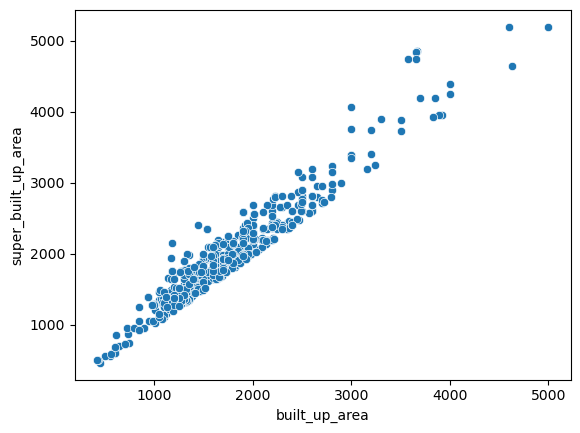

In [25]:
sns.scatterplot(x=df['built_up_area'],y=df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

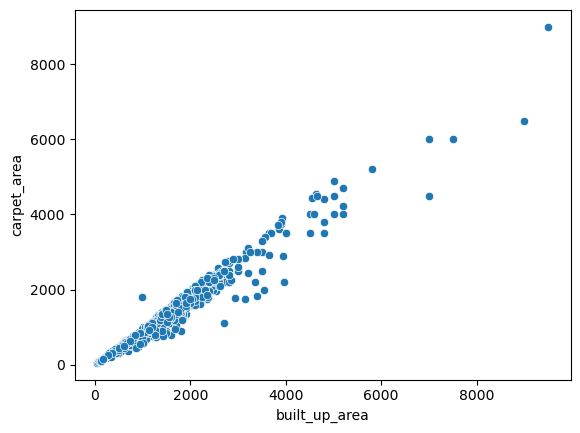

In [27]:
sns.scatterplot(x=df['built_up_area'],y=df['carpet_area'])

In [28]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))

0       False
1       False
2       False
3       False
4       False
        ...  
3552    False
3553    False
3554    False
3555    False
3556    False
Length: 3557, dtype: bool

In [29]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [30]:
all_present_df.shape

(528, 24)

In [31]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [32]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [33]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.1048701298701298 0.900140056022409


In [34]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [35]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
11,flat,puri emerald bay,sector 104,2.23,9911.0,2250.0,Super Built up area 2450(227.61 sq.m.)Carpet a...,3,4,3+,10.0,East,Relatively New,2450.0,NaN,2250.0,0,1,0,0,0,1,159,750.000000
34,flat,mm soulitude,sector 89,1.30,8701.0,1494.0,Super Built up area 1500(139.35 sq.m.)Carpet a...,3,3,2,1.0,NaN,New Property,1500.0,NaN,900.0,0,0,0,0,1,0,45,498.000000
48,flat,emaar mgf emerald estate,sector 65,1.70,21014.0,809.0,Super Built up area 1395(129.6 sq.m.)Carpet ar...,3,3,3,7.0,South-East,Relatively New,1395.0,NaN,809.0,1,0,0,0,0,1,116,269.666667
60,flat,bestech park view city,sector 48,1.78,10023.0,1776.0,Super Built up area 1776(165 sq.m.)Carpet area...,3,4,2,5.0,NaN,Relatively New,1776.0,NaN,1300.0,1,0,0,1,0,0,53,592.000000
62,flat,emaar mgf the palm drive,sector 66,4.60,18400.0,2500.0,Super Built up area 3300(306.58 sq.m.)Carpet a...,3,3,3,11.0,North,Relatively New,3300.0,NaN,2500.0,1,1,1,1,0,0,131,833.333333


In [36]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_22520\1215074969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_22520\1215074969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s

In [37]:
df.update(sbc_df)

In [38]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                140
facing                 1010
agePossession             0
super_built_up_area    1687
built_up_area          1554
carpet_area            1713
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [39]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [40]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
1,flat,ats tourmaline,sector 109,1.75,8140.0,2150.0,Super Built up area 2150(199.74 sq.m.),3,4,3+,9.0,North-East,Relatively New,2150.0,NaN,NaN,0,1,0,0,0,0,94,716.666667
9,flat,bptp terra,sector 37d,1.72,7850.0,2191.0,Super Built up area 2191(203.55 sq.m.),3,3,3+,10.0,South-East,Relatively New,2191.0,NaN,NaN,0,1,0,0,0,0,31,730.333333
10,flat,signature global park,sohna road,0.65,5637.0,1153.0,Super Built up area 1153(107.12 sq.m.),2,2,2,2.0,North-West,Relatively New,1153.0,NaN,NaN,0,0,0,1,0,0,118,576.500000
12,flat,bestech altura,sector 79,1.90,8837.0,2150.0,Super Built up area 2150(199.74 sq.m.),3,4,3,11.0,North-East,Under Construction,2150.0,NaN,NaN,0,0,0,0,0,0,96,716.666667
15,flat,tulip violet,sector 69,1.42,8999.0,1578.0,Super Built up area 1578(146.6 sq.m.),3,3,2,8.0,East,Relatively New,1578.0,NaN,NaN,0,0,0,1,0,1,94,526.000000


In [41]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_22520\1714170073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_22520\1714170073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(round(sb_

In [42]:
df.update(sb_df)

In [43]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                140
facing                 1010
agePossession             0
super_built_up_area    1687
built_up_area           680
carpet_area            1713
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [44]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [45]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
7,flat,birla navya,sector 63a,2.1,16667.0,1260.0,Carpet area: 1260 (117.06 sq.m.),2,2,2,2.0,NaN,Undefined,NaN,NaN,1260.0,0,0,0,0,0,0,38,630.0
13,flat,pivotal riddhi siddhi,sector 99,0.5,8518.0,587.0,Carpet area: 587 (54.53 sq.m.),2,1,2,7.0,NaN,New Property,NaN,NaN,587.0,0,0,0,0,0,0,24,293.5
14,flat,gls arawali homes,sohna road,0.3,4688.0,640.0,Carpet area: 640 (59.46 sq.m.),2,2,2,4.0,NaN,Relatively New,NaN,NaN,640.0,0,0,0,0,0,0,42,320.0
25,flat,tulip ivory,sector 70,5.0,10417.0,4800.0,Carpet area: 4800 (445.93 sq.m.),6,7,3+,NaN,NaN,Relatively New,NaN,NaN,4800.0,1,1,0,0,0,0,119,800.0
30,flat,pivotal devaan,sector 84,0.3,6667.0,450.0,Carpet area: 450 (41.81 sq.m.),1,1,1,14.0,NaN,New Property,NaN,NaN,450.0,0,0,0,0,0,1,22,450.0


In [46]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_22520\2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_22520\2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carpet_are

In [47]:
df.update(c_df)

In [48]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                140
facing                 1010
agePossession             0
super_built_up_area    1687
built_up_area             0
carpet_area            1713
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

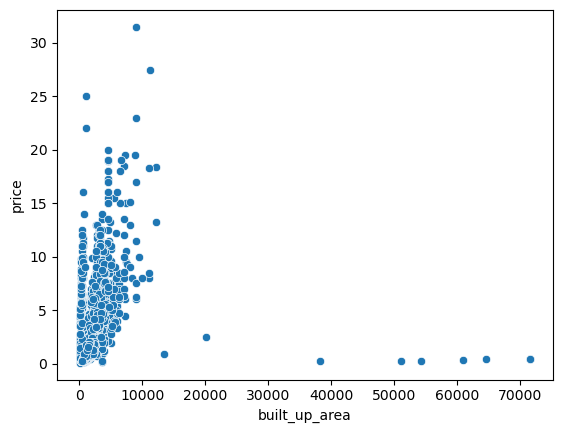

In [50]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [51]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [52]:
anamoly_df.sample(5)

,price,area,built_up_area
221,2.85,1975.0,1787.0
2887,5.15,3660.0,340.0
367,2.60,1766.0,1475.0
2286,3.50,1975.0,1787.0
2031,2.90,2003.0,1813.0


In [53]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [54]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

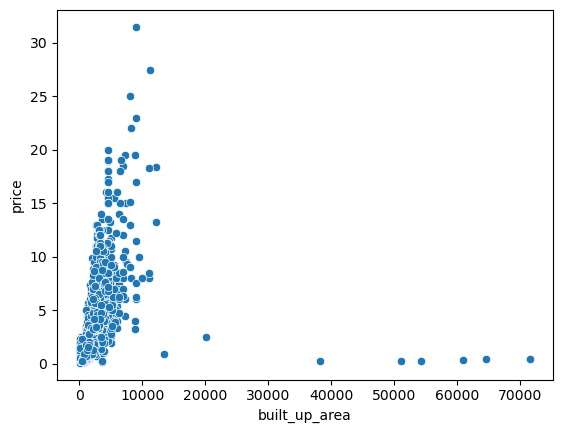

In [56]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [57]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)

In [58]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 15,1.07,11889.0,2,2,1,1.0,NaN,Old Property,900.0,0,1,0,0,0,0,7
1,flat,ats tourmaline,sector 109,1.75,8140.0,3,4,3+,9.0,North-East,Relatively New,1946.0,0,1,0,0,0,0,94
2,flat,paras dews,sector 106,1.10,9735.0,3,4,3+,8.0,North-West,Relatively New,1186.0,0,1,0,0,0,1,174
3,house,independent,sector 12,1.00,8230.0,3,7,3+,3.0,North,Moderately Old,3750.0,0,0,1,1,0,0,7
4,house,international city by sobha phase 1,sector 109,6.00,24691.0,4,5,3+,2.0,North,Relatively New,2430.0,0,1,0,0,0,1,96


In [59]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum            140
facing             1010
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

### floorNum

In [60]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
25,flat,tulip ivory,sector 70,5.00,10417.0,6,7,3+,NaN,NaN,Relatively New,5333.0,1,1,0,0,0,0,119
27,house,independent,sector 4,0.65,11111.0,4,2,2,NaN,NaN,Moderately Old,585.0,0,0,0,0,0,0,0
43,flat,ansal harmony homes,sector 57,1.12,10667.0,2,2,1,NaN,NaN,Old Property,950.0,0,0,0,0,0,0,72
114,flat,shapoorji pallonji joyville gurugram,sector 102,1.30,17687.0,2,2,3,NaN,East,Relatively New,1009.0,0,0,1,0,0,0,125
214,flat,mm woodshire,sector 107,1.15,7497.0,2,2,3,NaN,North-East,Relatively New,1281.0,1,0,0,0,0,0,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3391,flat,pyramid urban,sector 67a,0.56,7932.0,2,2,2,NaN,North-East,Relatively New,778.0,0,0,0,0,1,0,49
3424,flat,raheja vedaanta,sector 108,1.25,5682.0,3,2,0,NaN,NaN,Relatively New,1991.0,0,0,0,0,0,1,65
3481,flat,ild greens,sector 37c,0.95,5067.0,3,3,3+,NaN,NaN,New Property,1697.0,0,0,0,0,0,0,51
3482,flat,tulip violet,sector 69,2.00,9950.0,4,4,2,NaN,West,Relatively New,1819.0,0,0,0,0,0,0,95


In [61]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [62]:
df['floorNum'].fillna(2.0,inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_22520\15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [63]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1010
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

In [64]:
1011/df.shape[0]

0.28422828226033175

### facing

<Axes: ylabel='count'>

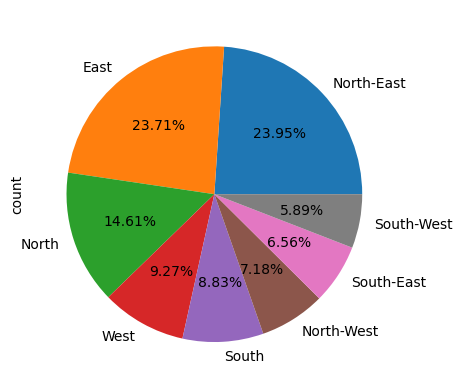

In [65]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [66]:
df.drop(columns=['facing'],inplace=True)

In [67]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
746,flat,mm capital,sector 113,2.00,12012.0,3,3,2,24.0,Under Construction,1507.0,0,0,0,0,0,0,47
1138,house,grover homes sec 4,sector 4,4.75,9374.0,5,5,1,1.0,Old Property,5067.0,1,1,0,1,0,1,35
199,flat,umang monsoon breeze,sector 78,0.75,6053.0,2,2,1,5.0,Undefined,1239.0,0,0,0,0,0,0,0
981,flat,smart world orchard,sector 110,2.20,13497.0,3,3,2,1.0,Undefined,1778.0,0,0,0,0,0,0,49
103,flat,tulip violet,sector 69,1.68,8358.0,4,4,2,7.0,Relatively New,1819.0,0,0,0,0,0,0,127


In [68]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [69]:
df.drop(index=[2536],inplace=True)

In [70]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

### agePossession

In [71]:
df['agePossession'].value_counts()

agePossession
Relatively New        1604
New Property           558
Moderately Old         545
Undefined              423
Old Property           293
Under Construction     133
Name: count, dtype: int64

In [72]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
7,flat,birla navya,sector 63a,2.10,16667.0,2,2,2,2.0,Undefined,1400.0,0,0,0,0,0,0,38
47,flat,ashiana anmol,sohna road,0.90,7059.0,2,2,2,8.0,Undefined,1275.0,0,0,0,0,0,0,0
63,flat,tulip petals,sector 89,1.10,7097.0,3,2,3,4.0,Undefined,1550.0,0,0,0,0,0,0,0
65,flat,dnha cghs,sector 1,0.85,3864.0,3,3,0,5.0,Undefined,2200.0,0,0,0,0,0,0,0
83,flat,signature global city d ph,sector 37d,1.07,8237.0,3,3,2,2.0,Undefined,1450.0,0,0,0,0,0,0,86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3504,flat,raheja navodaya,sector 92,1.10,4681.0,3,2,3,2.0,Undefined,2350.0,0,0,0,0,0,0,0
3506,flat,umang winter hills,sector 77,1.20,6586.0,3,3,3,14.0,Undefined,1822.0,0,0,0,0,0,0,46
3507,flat,sare green parc,sector 92,0.75,4820.0,3,2,2,16.0,Undefined,1556.0,0,0,0,0,0,0,0
3510,flat,avl gurgaon,sector 36a,0.50,8333.0,1,1,1,5.0,Undefined,600.0,0,0,0,0,0,0,0


In [73]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [74]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [75]:
df['agePossession'].value_counts()

agePossession
Relatively New        1794
New Property           622
Moderately Old         585
Old Property           330
Under Construction     135
Undefined               90
Name: count, dtype: int64

In [76]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [77]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [78]:
df['agePossession'].value_counts()

agePossession
Relatively New        1808
New Property           646
Moderately Old         592
Old Property           341
Under Construction     135
Undefined               34
Name: count, dtype: int64

In [79]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [80]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [81]:
df['agePossession'].value_counts()

agePossession
Relatively New        1819
New Property           646
Moderately Old         615
Old Property           341
Under Construction     135
Name: count, dtype: int64

In [82]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [83]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)

In [84]:
df.shape

(3556, 18)